# Exploratory Data Analysis for traning data

In [20]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Configure beautiful plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

In [22]:
PROJECT_ROOT = Path("..").resolve()
TRAIN_FILE = PROJECT_ROOT / "data" / "train" / "train.jsonl"

data = []

# Load and parse the Unsloth conversational format
with open(TRAIN_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            item = json.loads(line)
            # Extract text and labels from the 'messages' structure
            text = item["messages"][1]["content"]
            labels_str = item["messages"][2]["content"]
            
            # Reconstruct the list from the semicolon delimiter
            labels = labels_str.split("; ")
            
            data.append({
                "text": text, 
                "labels": labels, 
                "text_length": len(text.split()),
                "num_labels": len(labels)
            })

df = pd.DataFrame(data)
print(f"Successfully loaded {len(df)} training examples.")
display(df.head())

Successfully loaded 276 training examples.


,text,labels,text_length,num_labels
0,"My sister called last week, upset that I misse...","[I am unlovable, I am undesirable, unwanted, I...",157,6
1,Me and my older brother have always been close...,"[I am trapped, I am out of control, I am defec...",270,8
2,I spent the last two weeks studying for my che...,"[I am incompetent, I am a failure, loser]",151,2
3,Has anyone else had a long-term client just va...,"[I am a victim, I am needy, I am bound to be r...",159,5
4,I don't know how everyone else does this. I ha...,"[I am out of control, I am defective]",132,2


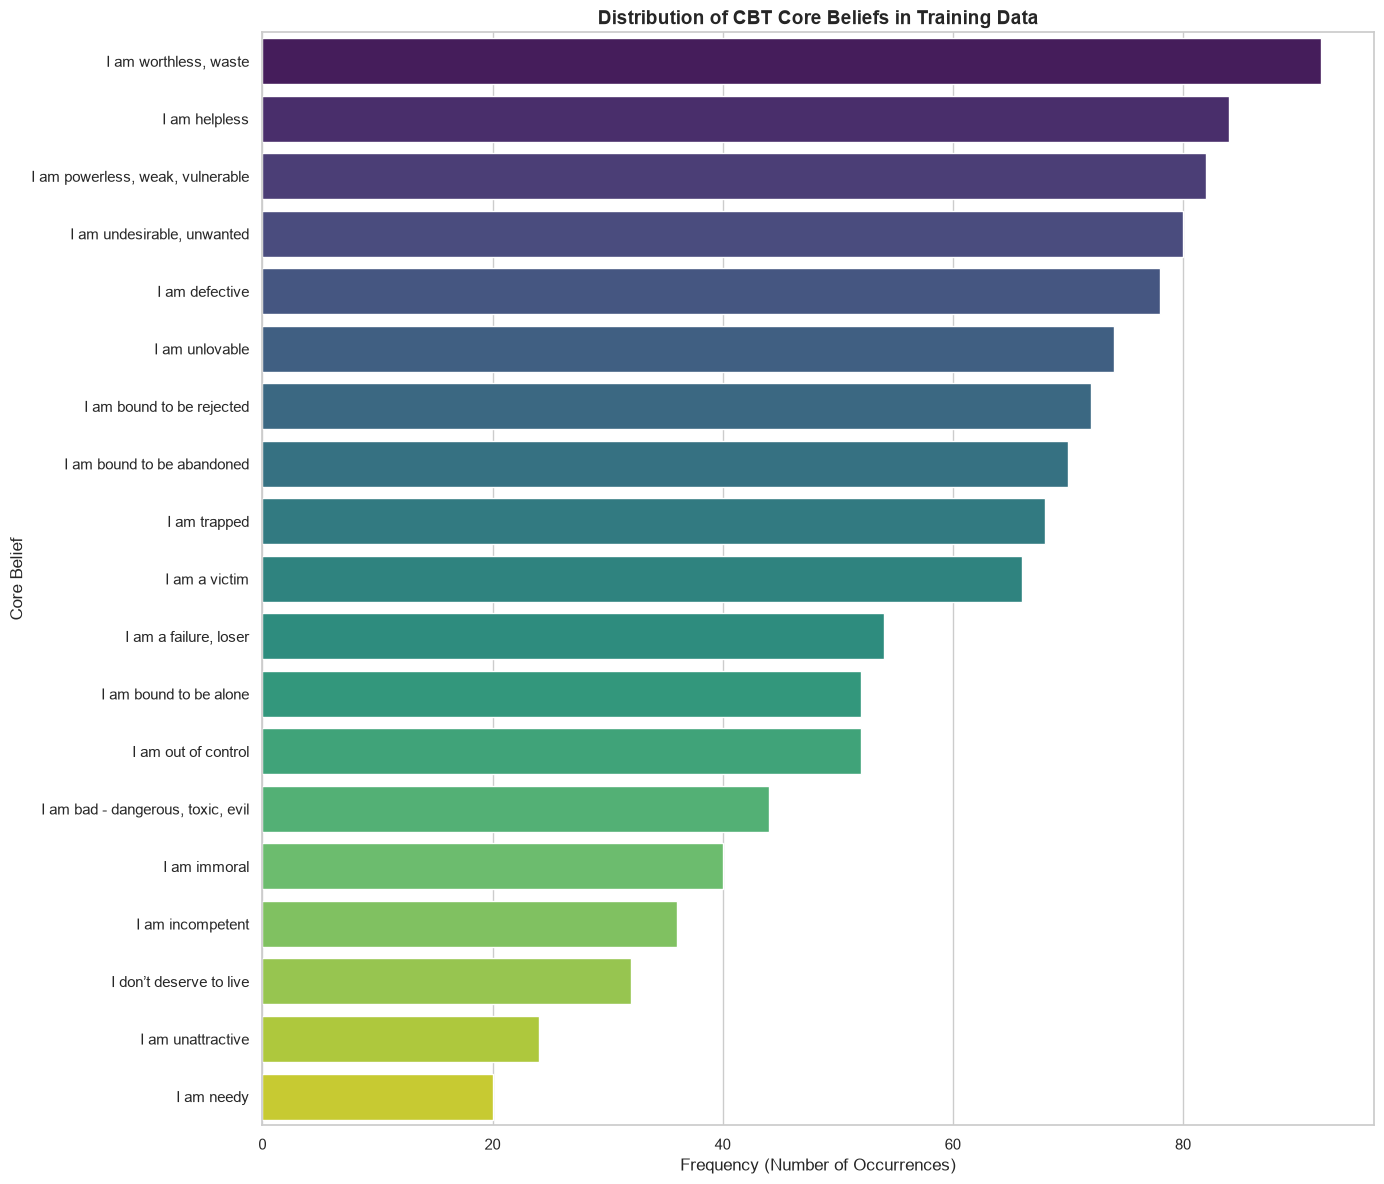

In [23]:
# Flatten the list of labels to count individual occurrences
all_labels = [label for sublist in df['labels'] for label in sublist]
label_counts = Counter(all_labels)

df_labels = pd.DataFrame(label_counts.items(), columns=['Core Belief', 'Frequency'])
df_labels = df_labels.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(14, 12))
sns.barplot(data=df_labels, x='Frequency', y='Core Belief', palette='viridis')

plt.title('Distribution of CBT Core Beliefs in Training Data')
plt.xlabel('Frequency (Number of Occurrences)')
plt.ylabel('Core Belief')
plt.tight_layout()
plt.show()

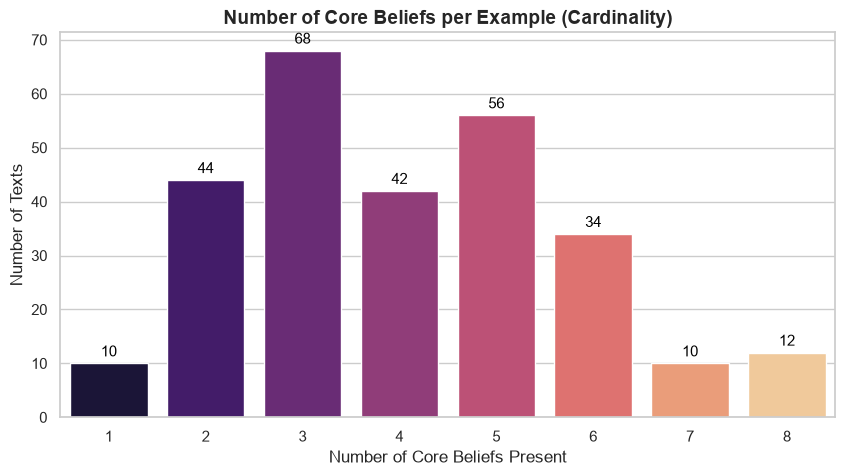

In [24]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='num_labels', palette='magma')

plt.title('Number of Core Beliefs per Example (Cardinality)')
plt.xlabel('Number of Core Beliefs Present')
plt.ylabel('Number of Texts')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

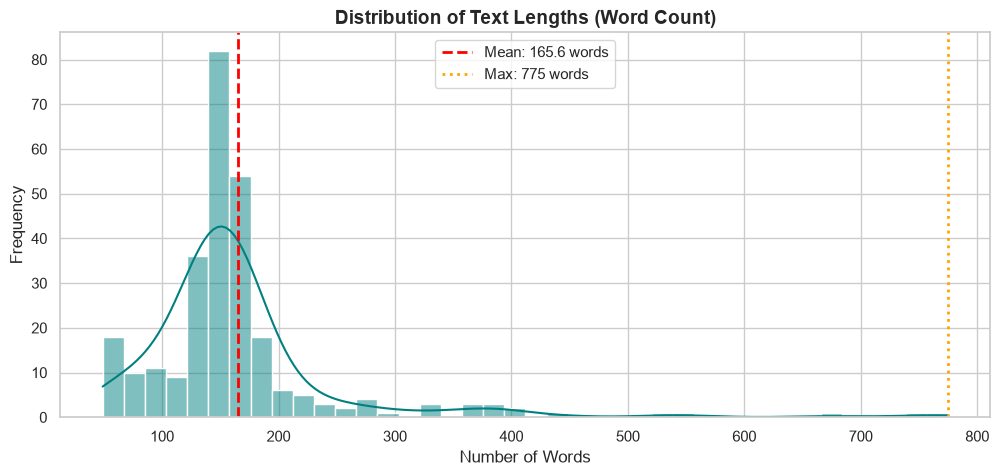

In [25]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='text_length', bins=40, kde=True, color='teal')

mean_len = df['text_length'].mean()
max_len = df['text_length'].max()

plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_len:.1f} words')
plt.axvline(max_len, color='orange', linestyle='dotted', linewidth=2, label=f'Max: {max_len} words')

plt.title('Distribution of Text Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Loading Llama-3 Tokenizer...
Tokenizing entire dataset to find exact sequence lengths...


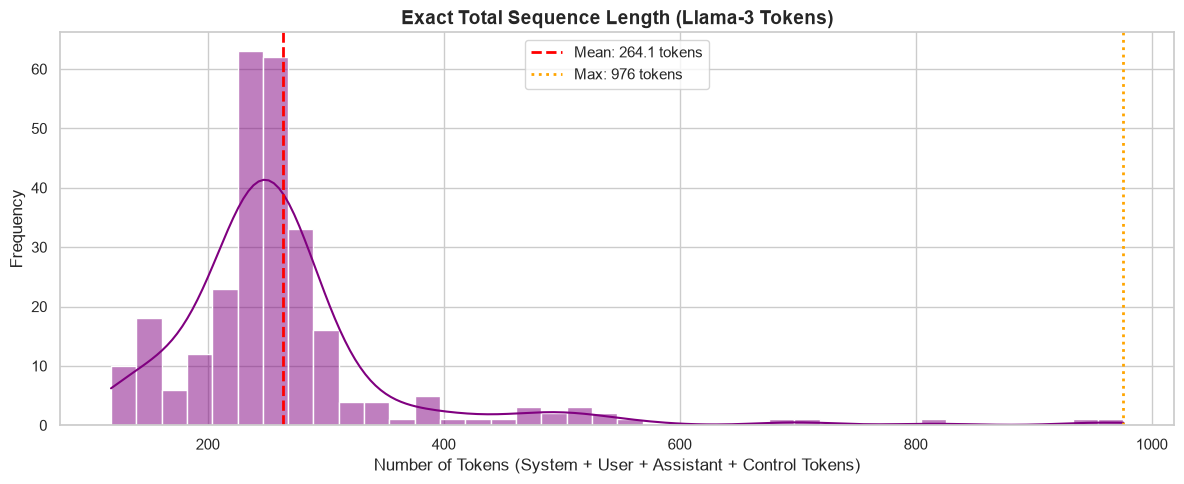

To avoid any truncation, set your max_seq_length > 976


In [27]:
from transformers import AutoTokenizer

print("Loading Llama-3 Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct")

# Function to calculate exact tokens for the FULL formatted sequence
def calculate_exact_tokens(row):
    # Reconstruct the exact Unsloth 'messages' format from prepare_dataset.py
    messages = [
        {"role": "system", "content": "Identify the underlying core beliefs from the narrative text."},
        {"role": "user", "content": row["text"]},
        {"role": "assistant", "content": "; ".join(row["labels"])}
    ]
    
    # apply_chat_template injects ALL control tokens (<|start_header_id|>, <|eot_id|>, etc.)
    token_ids = tokenizer.apply_chat_template(messages, tokenize=True)
    
    return len(token_ids)

print("Tokenizing entire dataset to find exact sequence lengths...")
df['total_tokens'] = df.apply(calculate_exact_tokens, axis=1)

# Plot token distribution
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='total_tokens', bins=40, kde=True, color='purple')

mean_tokens = df['total_tokens'].mean()
max_tokens = df['total_tokens'].max()

plt.axvline(mean_tokens, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_tokens:.1f} tokens')
plt.axvline(max_tokens, color='orange', linestyle='dotted', linewidth=2, label=f'Max: {max_tokens} tokens')

plt.title('Exact Total Sequence Length (Llama-3 Tokens)')
plt.xlabel('Number of Tokens (System + User + Assistant + Control Tokens)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"To avoid any truncation, set your max_seq_length > {max_tokens}")